In [1]:
# 开启自动重载，修改 Analysis.py 后自动生效
%load_ext autoreload
%autoreload 2

import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, JSON

# 插入你的模块路径
sys.path.insert(0, "/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis/")

# 导入你写的类和调度器
from vasp_analysis_mod.Analysis import RelaxAnalysis, DosAnalysis, CohpAnalysis, dispatch

# 定义测试文件夹路径 (请确保路径正确)
RELAX_DIR   = Path("/data2/home/luodh/Test/VaspAnalysis-Test/Relax-Test")
DOS_DIR     = Path("/data2/home/luodh/Test/VaspAnalysis-Test/Doscar-Text")
LOBSTER_DIR = Path("/data2/home/luodh/Test/VaspAnalysis-Test/Lobster-Text")

# 设置画图全局样式
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12


In [ ]:
print("=== 1. 测试 RelaxAnalysis ===")
relax_analyzer = RelaxAnalysis(RELAX_DIR)
relax_response = relax_analyzer.analyze(get_site_mag=True)

# Relax 返回的是 ApiResponse 对象
if relax_response.success:
    print("✅ Relax 解析成功！")
    data = relax_response.data
    data = relax_response.data
    print(f"最终能量: {data.get('final_energy_eV')} eV")
    print(f"费米能级: {data.get('fermi_level_eV')} eV")
    print(f"离子步数: {data.get('ionic_steps')}")
    # 获取总电子数 (对应 nelect)
    print(f"总电子数: {data.get('total_electrons')}")
    # 获取总磁矩 (对应 total_mag)
    print(f"总磁矩:   {data.get('total_magnetization')} μB")
    print(f"是否收敛: {data.get('converged')}")
    print(f"磁矩分布: {data.get('site_magnetization')}")
    print(f"dE: {data.get('last_dE_eV')}")
else:
    print(f"❌ 解析失败: {relax_response.message}")
    

    

=== 1. 测试 RelaxAnalysis ===
✅ Relax 解析成功！
最终能量: -241.68384 eV
费米能级: 0.3104 eV
离子步数: 125
总电子数: 1107.0
总磁矩:   -3.9350425 μB
是否收敛: True
磁矩分布: [{'atom_index': 0, 's': 0.004, 'p': -0.005, 'd': 2.051, 'tot': 2.05}, {'atom_index': 1, 's': 0.004, 'p': -0.004, 'd': 2.053, 'tot': 2.052}, {'atom_index': 2, 's': 0.004, 'p': -0.004, 'd': 2.071, 'tot': 2.071}, {'atom_index': 3, 's': 0.004, 'p': -0.004, 'd': 2.064, 'tot': 2.064}, {'atom_index': 4, 's': 0.009, 'p': -0.009, 'd': 2.076, 'tot': 2.075}, {'atom_index': 5, 's': 0.009, 'p': -0.01, 'd': 2.073, 'tot': 2.073}, {'atom_index': 6, 's': 0.009, 'p': -0.01, 'd': 2.081, 'tot': 2.08}, {'atom_index': 7, 's': 0.009, 'p': -0.01, 'd': 2.081, 'tot': 2.081}, {'atom_index': 8, 's': -0.003, 'p': 0.012, 'd': -2.017, 'tot': -2.008}, {'atom_index': 9, 's': -0.003, 'p': 0.011, 'd': -2.036, 'tot': -2.029}, {'atom_index': 10, 's': -0.003, 'p': 0.011, 'd': -2.063, 'tot': -2.055}, {'atom_index': 11, 's': -0.002, 'p': 0.012, 'd': -2.051, 'tot': -2.04}, {'atom_index': 1

In [3]:
print("=== 2. 测试 DosAnalysis (数据与统计) ===")
dos_analyzer = DosAnalysis(DOS_DIR)

# 调用 analyze()，当前代码返回的是字典
dos_response = dos_analyzer.analyze(orbital="d", erange=[-10, 5])

if dos_response.get("status") == "success":
    print("✅ DOS 解析成功！(Pandas 加速版)")
    dos_data = dos_response.get("data", {})
    
    print(f"是否自旋极化: {dos_data.get('is_spin_polarized')}")
    print(f"体系包含原子数: {dos_data.get('n_ions')}")
    print(f"NEDOS (数据点数): {dos_data.get('nedos')}")
    
    print("\n--- 轨道统计信息 (d-band center 等) ---")
    display(JSON(dos_data.get('orbital_statistics', {})))
else:
    print(f"❌ 解析失败: {dos_response.get('message')}")


/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis/vasp_analysis_mod/Analysis.py:429: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  tdos_df = pd.read_csv(
/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis/vasp_analysis_mod/Analysis.py:451: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pdos_raw_df = pd.read_csv(



=== 2. 测试 DosAnalysis (数据与统计) ===
✅ DOS 解析成功！(Pandas 加速版)
是否自旋极化: True
体系包含原子数: 80
NEDOS (数据点数): 3001

--- 轨道统计信息 (d-band center 等) ---


<IPython.core.display.JSON object>

=== 3. 测试 DosAnalysis (可视化) ===


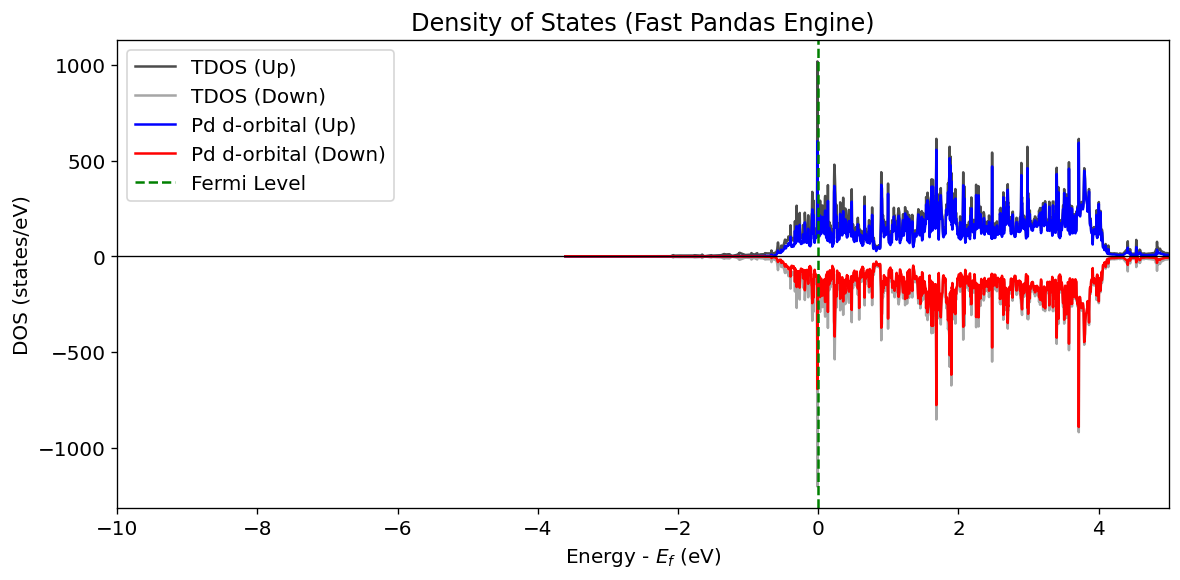

In [4]:
print("=== 3. 测试 DosAnalysis (可视化) ===")

# 获取 DataFrame
tdos_df = dos_analyzer.get_total_dos()
espd_df = dos_analyzer.get_element_spd_dos()
is_spin = dos_analyzer.is_spin

plt.figure(figsize=(10, 5))

# 1. 画总态密度 (TDOS)
plt.plot(tdos_df['energy_eV'], tdos_df['tdos_up'], label='TDOS (Up)', color='black', alpha=0.7)
if is_spin and 'tdos_down' in tdos_df.columns:
    plt.plot(tdos_df['energy_eV'], -tdos_df['tdos_down'], label='TDOS (Down)', color='gray', alpha=0.7)

# 2. 画分波态密度 (PDOS) - 自动找第一个元素
elements = list(dict.fromkeys(dos_analyzer.site_elements))
if elements:
    target_el = elements[0]
    col_up = f"{target_el}_d_up" if is_spin else f"{target_el}_d"
    col_dn = f"{target_el}_d_down"
    
    if col_up in espd_df.columns:
        plt.plot(espd_df['energy_eV'], espd_df[col_up], label=f'{target_el} d-orbital (Up)', color='blue')
    if is_spin and col_dn in espd_df.columns:
        plt.plot(espd_df['energy_eV'], -espd_df[col_dn], label=f'{target_el} d-orbital (Down)', color='red')

plt.axvline(0, color='green', linestyle='--', label='Fermi Level')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlim(-10, 5)
plt.xlabel('Energy - $E_f$ (eV)')
plt.ylabel('DOS (states/eV)')
plt.title('Density of States (Fast Pandas Engine)')
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
print("=== 4. 测试 CohpAnalysis (数据提取) ===")
cohp_analyzer = CohpAnalysis(LOBSTER_DIR)

# 获取前 5 个最强的键
cohp_response = cohp_analyzer.analyze(n_top_bonds=5)

if cohp_response.success:
    print("✅ COHP 解析成功！")
    # 直接获取 DataFrame 格式的 ICOHP 汇总表展示
    icohp_summary_df = cohp_analyzer.get_icohp_summary(n_top=10)
    print("\n--- ICOHP 键合强度汇总 (前 10 个) ---")
    display(icohp_summary_df)
else:
    print(f"❌ 解析失败: {cohp_response.message}")

=== 4. 测试 CohpAnalysis (数据提取) ===
✅ COHP 解析成功！

--- ICOHP 键合强度汇总 (前 10 个) ---


,bond_label,atom1,atom2,length_Ang,icohp_eV
0,2,Pd65,C153,2.14707,-2.68477
1,1,Pd64,C152,2.15130,-2.67223


In [6]:
print("=== 5. 测试统一调度器 (Dispatcher) ===")

# 模拟 Java 后端调用
json_result = dispatch("relax", RELAX_DIR)

print("Java 后端将收到的纯 JSON 字符串 (前500个字符):")
print("-" * 50)
print(json_result[:500] + "\n... [截断]")
print("-" * 50)

# 验证 JSON 是否可以被成功解析
try:
    parsed_dict = json.loads(json_result)
    print(f"\n✅ JSON 格式合法！解析状态码: {parsed_dict.get('code')}")
except json.JSONDecodeError:
    print("\n❌ JSON 格式不合法！")

=== 5. 测试统一调度器 (Dispatcher) ===
Java 后端将收到的纯 JSON 字符串 (前500个字符):
--------------------------------------------------
{"success": true, "code": 200, "message": "Relax analysis complete: converged", "data": {"converged": true, "final_energy_eV": -241.68384, "fermi_level_eV": 0.3104, "total_electrons": 1107.0, "ionic_steps": 125, "electronic_steps_per_ionic": [100, 96, 11, 10, 19, 25, 17, 22, 17, 13, 16, 25, 17, 9, 21, 15, 8, 22, 8, 12, 9, 8, 9, 25, 18, 9, 8, 21, 8, 14, 8, 22, 10, 15, 8, 20, 8, 8, 11, 8, 15, 9, 9, 19, 8, 8, 8, 8, 12, 11, 8, 8, 13, 8, 8, 8, 9, 10, 19, 8, 8, 8, 8, 8, 8, 11, 9, 11, 8, 8, 11, 8, 9, 8
... [截断]
--------------------------------------------------

✅ JSON 格式合法！解析状态码: 200


=== 测试 Relax 收敛数据提取与绘图 ===
✅ 成功获取收敛数据！数据预览：
   step  energy_eV       dE_eV   dE_abs_eV  electronic_steps
0     1 -240.49631 -240.596000  240.596000               100
1     2 -240.80508   -0.284794    0.284794                96
2     3 -240.84021   -0.319891    0.319891                11
3     4 -240.90331   -0.383012    0.383012                10
4     5 -240.99344   -0.473538    0.473538                19


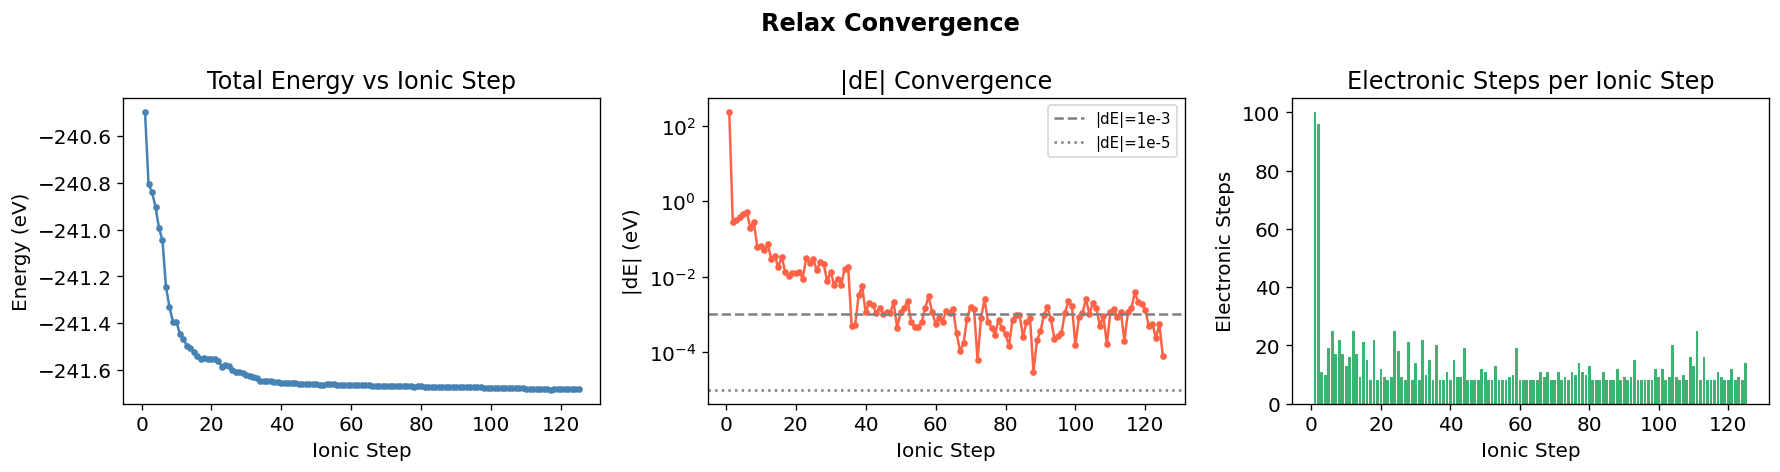

📊 统计信息: 总离子步: 125  |  平均电子步: 12.7


In [7]:
import matplotlib.pyplot as plt
import numpy as np

print("=== 测试 Relax 收敛数据提取与绘图 ===")
relax_analyzer = RelaxAnalysis(RELAX_DIR)

# 1. 获取数据 (模拟后端返回 JSON/DataFrame)
df_conv = relax_analyzer.get_convergence_data()

if df_conv is not None and not df_conv.empty:
    print("✅ 成功获取收敛数据！数据预览：")
    print(df_conv.head())
    
    # 2. 开始绘图 (模拟前端接收到数据后渲染)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Relax Convergence", fontweight="bold")

    # 子图1: 能量收敛
    axes[0].plot(df_conv['step'], df_conv['energy_eV'], color="steelblue", marker=".")
    axes[0].set_xlabel("Ionic Step")
    axes[0].set_ylabel("Energy (eV)")
    axes[0].set_title("Total Energy vs Ionic Step")

    # 子图2: dE 收敛 (对数坐标)
    axes[1].semilogy(df_conv['step'], df_conv['dE_abs_eV'], color="tomato", marker=".")
    axes[1].axhline(1e-3, color="gray", linestyle="--", label="|dE|=1e-3")
    axes[1].axhline(1e-5, color="gray", linestyle=":",  label="|dE|=1e-5")
    axes[1].set_xlabel("Ionic Step")
    axes[1].set_ylabel("|dE| (eV)")
    axes[1].set_title("|dE| Convergence")
    axes[1].legend(fontsize=9)

    # 子图3: 每离子步的电子步数
    axes[2].bar(df_conv['step'], df_conv['electronic_steps'], color="mediumseagreen", width=0.8)
    axes[2].set_xlabel("Ionic Step")
    axes[2].set_ylabel("Electronic Steps")
    axes[2].set_title("Electronic Steps per Ionic Step")

    plt.tight_layout()
    plt.show()
    
    print(f"📊 统计信息: 总离子步: {len(df_conv)}  |  平均电子步: {df_conv['electronic_steps'].mean():.1f}")
else:
    print("❌ 获取收敛数据失败！")


/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis/vasp_analysis_mod/Analysis.py:429: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  tdos_df = pd.read_csv(
/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis/vasp_analysis_mod/Analysis.py:451: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pdos_raw_df = pd.read_csv(



=== 7. 测试分位点/分轨道 DOS (Site & Orbital DOS) ===
🔍 正在提取元素 [Pd] 的 SPD DOS...
🔍 正在提取位点 [0] (Pd) 的 t2g/eg DOS...


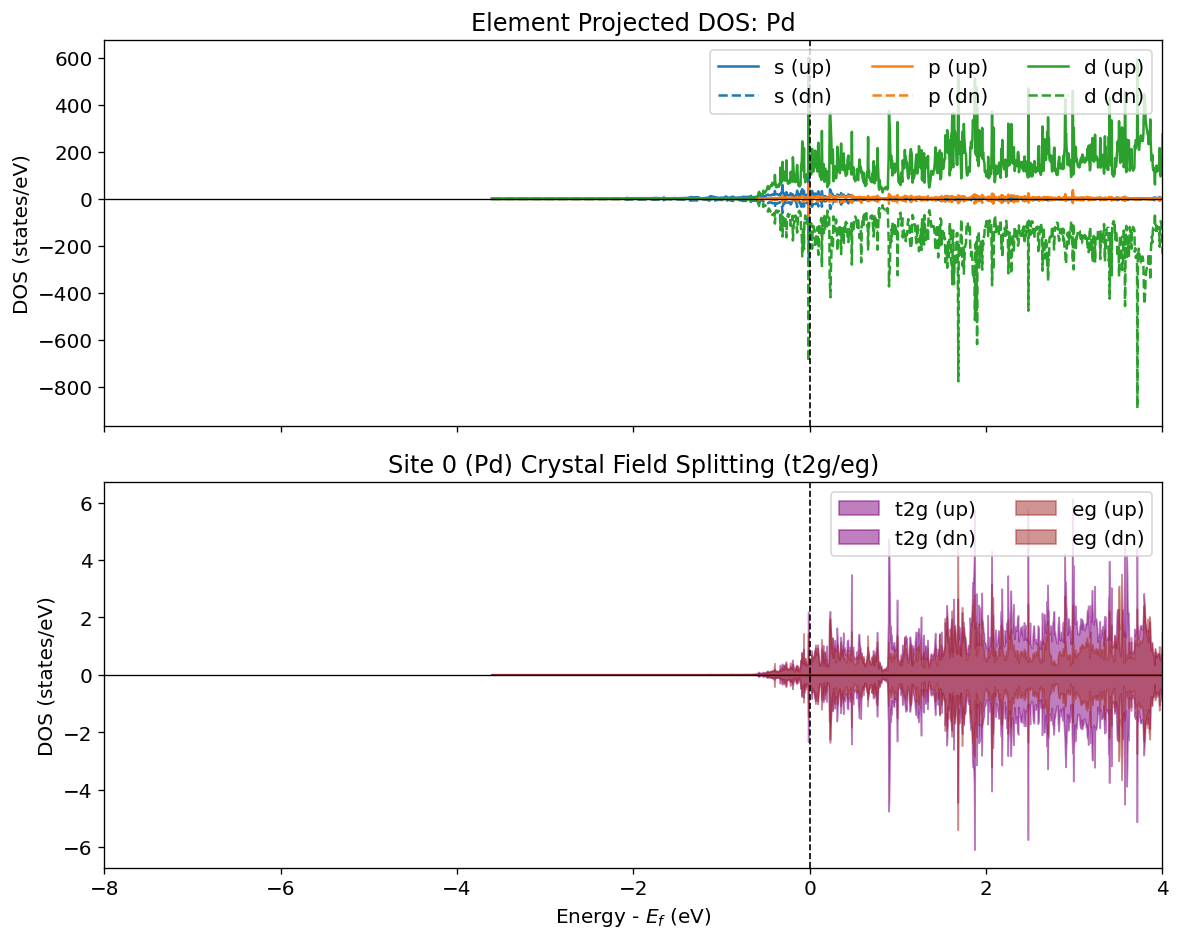

In [8]:
print("=== 7. 测试分位点/分轨道 DOS (Site & Orbital DOS) ===")

dos_analyzer = DosAnalysis(DOS_DIR)
is_spin = dos_analyzer.is_spin

# 自动获取体系中的第一个元素和第一个原子位点作为测试目标
elements = list(dict.fromkeys(dos_analyzer.site_elements))
target_el = elements[0] if elements else None
target_site = 0 

print(f"🔍 正在提取元素 [{target_el}] 的 SPD DOS...")
el_spd_df = dos_analyzer.get_element_spd_dos(element=target_el)

print(f"🔍 正在提取位点 [{target_site}] ({dos_analyzer.site_elements[target_site]}) 的 t2g/eg DOS...")
site_t2g_eg_df = dos_analyzer.get_site_t2g_eg_dos(site_index=target_site)

# --- 开始绘图 ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 图 1: 元素的 SPD DOS
if el_spd_df is not None:
    ax = axes[0]
    for orb, color in zip(['s', 'p', 'd'], ['#1f77b4', '#ff7f0e', '#2ca02c']):
        col_up = f"{target_el}_{orb}_up" if is_spin else f"{target_el}_{orb}"
        col_dn = f"{target_el}_{orb}_down"

        if col_up in el_spd_df.columns:
            ax.plot(el_spd_df['energy_eV'], el_spd_df[col_up], label=f'{orb} (up)', color=color)
        if is_spin and col_dn in el_spd_df.columns:
            # 自旋向下取负值，画在 X 轴下方
            ax.plot(el_spd_df['energy_eV'], -el_spd_df[col_dn], label=f'{orb} (dn)', color=color, linestyle='--')

    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel("DOS (states/eV)")
    ax.set_title(f"Element Projected DOS: {target_el}")
    ax.legend(loc='upper right', ncol=3)

# 图 2: 特定原子位点的 t2g / eg 分裂 (使用填充图更直观)
if site_t2g_eg_df is not None:
    ax = axes[1]
    for orb, color in zip(['t2g', 'eg'], ['purple', 'brown']):
        col_up = f"{orb}_up" if is_spin else orb
        col_dn = f"{orb}_down"

        if col_up in site_t2g_eg_df.columns:
            ax.fill_between(site_t2g_eg_df['energy_eV'], 0, site_t2g_eg_df[col_up], label=f'{orb} (up)', color=color, alpha=0.5)
        if is_spin and col_dn in site_t2g_eg_df.columns:
            ax.fill_between(site_t2g_eg_df['energy_eV'], 0, -site_t2g_eg_df[col_dn], label=f'{orb} (dn)', color=color, alpha=0.5)

    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel("Energy - $E_f$ (eV)")
    ax.set_ylabel("DOS (states/eV)")
    ax.set_title(f"Site {target_site} ({dos_analyzer.site_elements[target_site]}) Crystal Field Splitting (t2g/eg)")
    ax.legend(loc='upper right', ncol=2)

# 设置一个合理的能量区间 (通常费米面附近最重要)
plt.xlim(-8, 4) 
plt.tight_layout()
plt.show()

=== 测试COHP分析 ===
✅ 成功获取 ICOHP 汇总数据！数据预览：
最强键: 2 (Pd65 - C153)
✅ 成功获取 COHP 曲线数据！数据预览：


,energy_eV,2_up
0,-35.03185,0.0
1,-34.98180,0.0
2,-34.93176,0.0
3,-34.88171,0.0
4,-34.83167,0.0


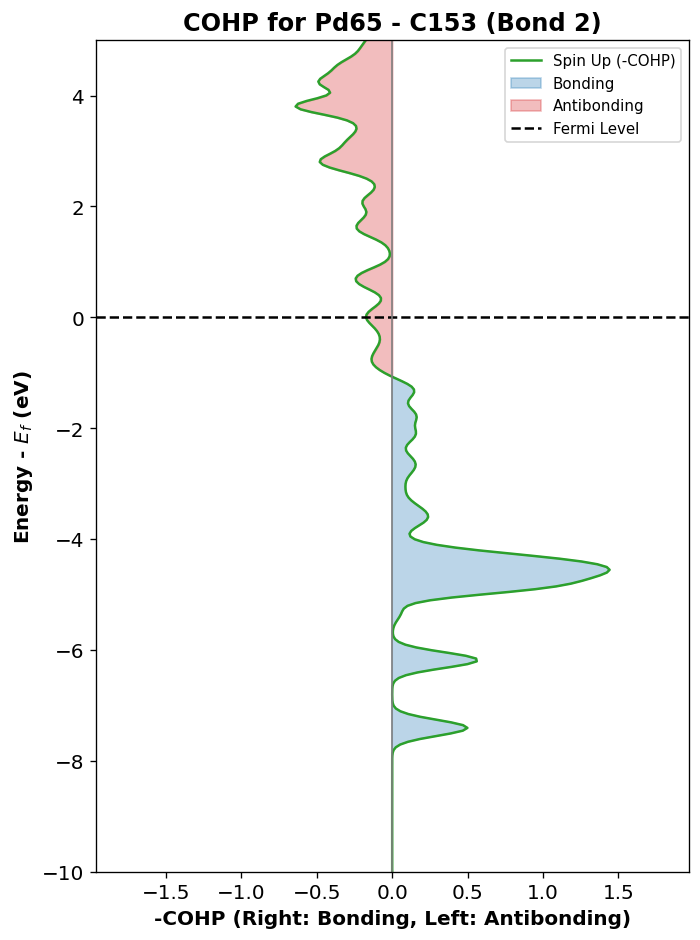

In [9]:
import matplotlib.pyplot as plt
import numpy as np

print ("=== 测试COHP分析 ===")
cohp_analyzer = CohpAnalysis(LOBSTER_DIR)
#获取ICOHP汇总，找出最强键
df_summary = cohp_analyzer.get_icohp_summary(n_top=5)
if df_summary is not None and not df_summary.empty:
    print("✅ 成功获取 ICOHP 汇总数据！数据预览：")
    best_bond_label = df_summary.iloc[0]["bond_label"]
    atom1 = df_summary.iloc[0]["atom1"]
    atom2 = df_summary.iloc[0]["atom2"]
    print(f"最强键: {best_bond_label} ({atom1} - {atom2})")
    
    # 获取该键的 COHP 数据
    df_cohp = cohp_analyzer.get_cohp_curves(bond_labels=[best_bond_label])
    if df_cohp is not None and not df_cohp.empty:
        print("✅ 成功获取 COHP 曲线数据！数据预览：")
        display(df_cohp.head())
        
        # ---------------------------------------------------------
        # 第三步：开始绘图 (遵循 -COHP 行业惯例)
        # ---------------------------------------------------------
        fig, ax = plt.subplots(figsize=(6, 8))
        
        y = df_cohp["energy_eV"]
        
        # 你的代码中列名是动态生成的，例如 "1_up"
        col_up = f"{best_bond_label}_up"
        
        if col_up in df_cohp.columns:
            # ⚠️ 核心惯例：画 -COHP (负值)，让右侧为成键，左侧为反键
            x_up = -df_cohp[col_up]
            
            # 绘制 Spin Up 曲线
            ax.plot(x_up, y, color="#2ca02c", linewidth=1.5, label=f"Spin Up (-COHP)")
            
            # 填充颜色：右侧(>0)为成键(蓝色)，左侧(<0)为反键(红色)
            ax.fill_betweenx(y, 0, x_up, where=(x_up > 0), color="#1f77b4", alpha=0.3, label="Bonding")
            ax.fill_betweenx(y, 0, x_up, where=(x_up < 0), color="#d62728", alpha=0.3, label="Antibonding")
            
            # 处理 Spin Down 数据 (如果体系是自旋极化的)
            col_down = f"{best_bond_label}_down"
            if col_down in df_cohp.columns:
                # 惯例：Spin Down 画在左侧，所以直接用原始值 (等价于 -(-COHP))
                x_down = df_cohp[col_down] 
                ax.plot(x_down, y, color="#ff7f0e", linewidth=1.5, label=f"Spin Down (-COHP)")
                # 注意 Spin Down 在左侧，所以 >0 和 <0 的物理意义在图上反过来了，但填充颜色逻辑保持一致
                ax.fill_betweenx(y, 0, x_down, where=(x_down < 0), color="#1f77b4", alpha=0.3)
                ax.fill_betweenx(y, 0, x_down, where=(x_down > 0), color="#d62728", alpha=0.3)

            # 辅助线：费米能级 (y=0) 和 零界线 (x=0)
            ax.axhline(0, color="black", linestyle="--", linewidth=1.5, label="Fermi Level")
            ax.axvline(0, color="gray", linestyle="-", linewidth=1)
            
            # 设置坐标轴范围 (通常我们只关注费米面附近的成键情况，比如 -10 到 5 eV)
            ax.set_ylim(-10, 5) 
            # 动态设置 X 轴范围，让图表居中对称
            x_max = max(abs(x_up.max()), abs(x_up.min())) * 1.2
            ax.set_xlim(-x_max, x_max)
            
            # 标签和标题
            ax.set_xlabel("-COHP (Right: Bonding, Left: Antibonding)", fontweight="bold")
            ax.set_ylabel("Energy - $E_f$ (eV)", fontweight="bold")
            ax.set_title(f"COHP for {atom1} - {atom2} (Bond {best_bond_label})", fontweight="bold")
            
            # 优化图例
            ax.legend(loc="upper right", fontsize=9)
            
            plt.tight_layout()
            plt.show()
    else:
        print("❌ 获取 COHP 曲线数据失败！")
else:
    print("❌ 获取 ICOHP 汇总失败！请检查目录下是否存在 ICOHPLIST.lobster 文件。")


=== 测试分轨道 COHP 提取与绘图 ===
👉 正在分析最强键: Label [2] (Pd65 - C153)
✅ 成功获取分轨道数据！包含的轨道组合：
['5s-2s_up', '5s-2py_up', '5s-2pz_up', '5s-2px_up', '5py-2s_up', '5py-2py_up', '5py-2pz_up', '5py-2px_up', '5pz-2s_up', '5pz-2py_up', '5pz-2pz_up', '5pz-2px_up', '5px-2s_up', '5px-2py_up', '5px-2pz_up', '5px-2px_up', '4dxy-2s_up', '4dxy-2py_up', '4dxy-2pz_up', '4dxy-2px_up', '4dyz-2s_up', '4dyz-2py_up', '4dyz-2pz_up', '4dyz-2px_up', '4dz2-2s_up', '4dz2-2py_up', '4dz2-2pz_up', '4dz2-2px_up', '4dxz-2s_up', '4dxz-2py_up', '4dxz-2pz_up', '4dxz-2px_up', '4dx2-2s_up', '4dx2-2py_up', '4dx2-2pz_up', '4dx2-2px_up']


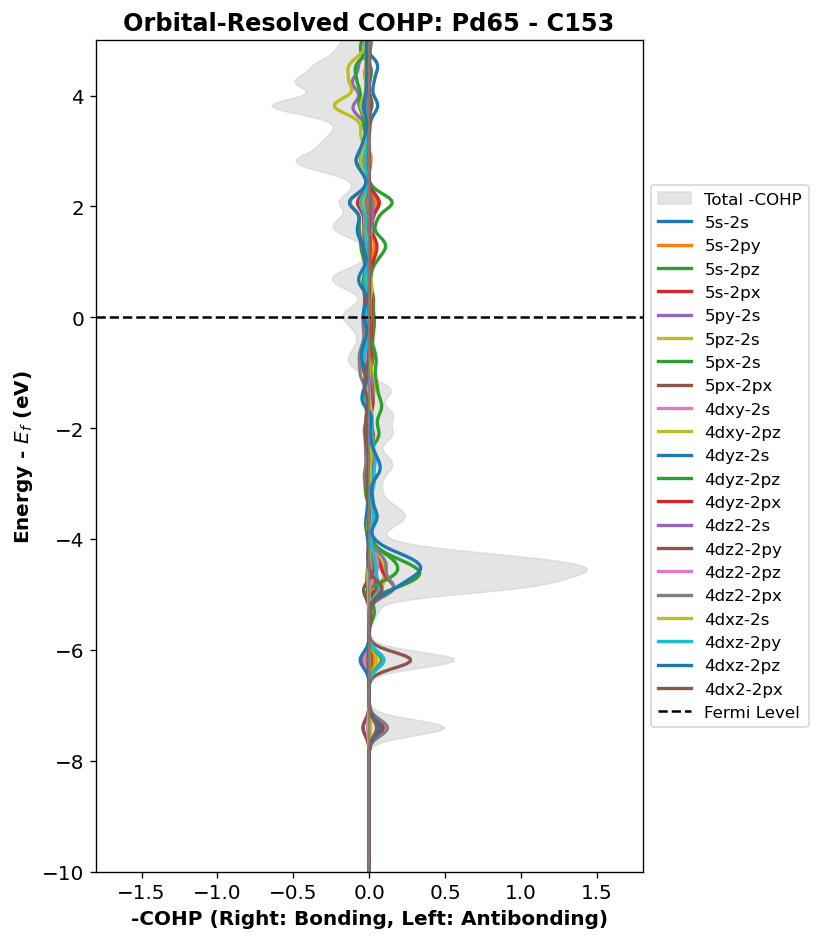

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

print("=== 测试分轨道 COHP 提取与绘图 ===")
# 初始化分析器
cohp_analyzer = CohpAnalysis(LOBSTER_DIR)

# 1. 获取最强键的 label
df_summary = cohp_analyzer.get_icohp_summary(n_top=1)
if df_summary is not None and not df_summary.empty:
    best_bond_label = df_summary.iloc[0]["bond_label"]
    atom1 = df_summary.iloc[0]["atom1"]
    atom2 = df_summary.iloc[0]["atom2"]
    print(f"👉 正在分析最强键: Label [{best_bond_label}] ({atom1} - {atom2})")
    
    # 2. 获取总 COHP 数据 (作为背景)
    df_total = cohp_analyzer.get_cohp_curves(bond_labels=[best_bond_label])
    
    # 3. 获取分轨道 COHP 数据
    df_orb = cohp_analyzer.get_orbital_cohp_curves(bond_label=best_bond_label)
    
    if df_orb is not None and not df_orb.empty:
        print("✅ 成功获取分轨道数据！包含的轨道组合：")
        # 打印出所有的列名 (排除 energy_eV)
        orb_cols = [c for c in df_orb.columns if c != "energy_eV"]
        print(orb_cols)
        
        # 4. 开始绘图
        fig, ax = plt.subplots(figsize=(7, 8))
        y = df_orb["energy_eV"]
        
        # --- 绘制总 COHP 背景 (灰色填充) ---
        col_total_up = f"{best_bond_label}_up"
        if df_total is not None and col_total_up in df_total.columns:
            x_total_up = -df_total[col_total_up] # 负号惯例
            ax.fill_betweenx(y, 0, x_total_up, color="lightgray", alpha=0.6, label="Total -COHP")
        
        # --- 绘制各个分轨道 COHP 曲线 ---
        # 挑选 Spin Up 的轨道数据进行绘制 (-COHP 惯例)
        up_cols = [c for c in orb_cols if c.endswith("_up")]
        
        # 使用 matplotlib 自带的颜色循环
        colors = plt.cm.tab10.colors 
        
        for i, col in enumerate(up_cols):
            orb_name = col.replace("_up", "") # 提取纯轨道名，例如 "4s-2p_x"
            x_orb_up = -df_orb[col]           # 负号惯例
            
            # 过滤掉贡献极小的轨道 (可选，让图更干净)
            if abs(x_orb_up).max() > 0.05: 
                ax.plot(x_orb_up, y, color=colors[i % len(colors)], linewidth=2, label=orb_name)

        # --- 辅助线与格式 ---
        ax.axhline(0, color="black", linestyle="--", linewidth=1.5, label="Fermi Level")
        ax.axvline(0, color="gray", linestyle="-", linewidth=1)
        
        ax.set_ylim(-10, 5)
        
        # 动态设置 X 轴范围
        x_max = max(abs(x_total_up.max()), abs(x_total_up.min())) * 1.1 if 'x_total_up' in locals() else 5
        ax.set_xlim(-x_max, x_max)
        
        ax.set_xlabel("-COHP (Right: Bonding, Left: Antibonding)", fontweight="bold")
        ax.set_ylabel("Energy - $E_f$ (eV)", fontweight="bold")
        ax.set_title(f"Orbital-Resolved COHP: {atom1} - {atom2}", fontweight="bold")
        
        # 把图例放在图外侧，防止遮挡曲线
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
        
        plt.tight_layout()
        plt.show()
    else:
        print("❌ 获取分轨道数据失败！(可能是 LOBSTER 计算时未开启分轨道输出)")
else:
    print("❌ 获取 ICOHP 汇总失败！")


In [11]:
Test2 = Path("/data2/home/luodh/work/DICP/new-particle/nospin/19/C2H4/cohp").resolve()

cohp_analyzer2 = CohpAnalysis(Test2)
#通过原子对的方法来获取相关的信息
df_summary2 = cohp_analyzer2.get_icohp_summary(element_pair=('Pd', 'C'))
print(df_summary2)

  bond_label atom1 atom2  length_Ang  icohp_eV
0        213  Pd18   C25     2.08338  -2.87559
1        218  Pd19   C24     2.08683  -2.86186
2        212  Pd18   C24     2.87023  -0.33315
3        219  Pd19   C25     2.88424  -0.32067
4        228  Pd21   C25     3.35899  -0.15572
5        227  Pd21   C24     3.36725  -0.15275
6        223  Pd20   C24     3.44115  -0.12916
7        224  Pd20   C25     3.46262  -0.12174
8        231  Pd22   C25     3.81684  -0.08569
9        232  Pd23   C24     3.85718  -0.08038


### 前后端测试

In [2]:
# 1. 强制重载外部修改的 Python 文件（解决缓存不更新的问题）
%load_ext autoreload
%autoreload 2

import json
# 假设 dispatch 已经导入
# from your_module.dispatcher import dispatch

# 请确保定义了 DOS_DIR
# DOS_DIR = "./your_test_data_folder" 

print("==================================================")
print("测试 1: 获取结构信息 (task_type='structure')")
print("==================================================")
resp_struct_json = dispatch(
    task_type="structure",
    work_dir = DOS_DIR
)
resp_struct = json.loads(resp_struct_json)

if resp_struct["success"]:
    print("✅ 结构解析成功！")
    print(f"总原子数: {resp_struct['data']['totalAtoms']}")
    print(f"包含元素: {resp_struct['data']['elements']}")
else:
    print("❌ 结构解析失败:", resp_struct["message"])


print("\n==================================================")
print("测试 2: 获取多条 DOS 曲线及统计信息 (task_type='dos_multi')")
print("==================================================")
# 模拟前端传来的 Payload
payload_dos = {
    "erange": [-10.0, 10.0],
    "show_tdos": True,
    "curves": [
        # 曲线1：按元素投影 (例如 Pd 的 d 轨道)
        # 注意：重构后的后端不强制要求 "type" 字段，它通过 element 或 site 键来判断
        {"id": "c1", "element": "Pd", "orbital": "d"},
        
        # 曲线2：按特定位点投影 (例如第 1 个原子的 d 轨道)
        # 注意：前端传来的 site 可能是字符串，后端已经做了兼容
        {"id": "c2", "site": "2", "orbital": "d"},
    ]
}

resp_dos_json = dispatch(
    task_type="dos_multi",  # <--- 修改点 1：使用 dos_multi 路由
    work_dir = DOS_DIR,
    **payload_dos
)
resp_dos = json.loads(resp_dos_json)

if resp_dos["success"]:
    print("✅ DOS 曲线解析成功！")
    data = resp_dos["data"]
    
    print(f"是否自旋极化: {data['is_spin_polarized']}")
    
    print("\n--- 曲线统计信息 (占据态 E < 0) ---")
    for curve in data["curves"]:
        print(f"\n曲线名称: {curve['name']} (ID: {curve['id']})")
        
        stats = curve.get("stats", {})
        
        # 遍历 up, down, total 分量
        for spin_type, spin_stats in stats.items():
            print(f"  [{spin_type.upper()}]")
            print(f"    - d带/能带中心 (Center): {spin_stats.get('center', 0):.4f} eV")
            print(f"    - 带宽 (Width): {spin_stats.get('width', 0):.4f} eV")
            print(f"    - 偏度 (Skewness): {spin_stats.get('skewness', 0):.4f}")
            print(f"    - 峰度 (Kurtosis): {spin_stats.get('kurtosis', 0):.4f}")
            print(f"    - 电子填充数 (Filling): {spin_stats.get('filling', 0):.4f}")
else:
    print("❌ DOS 解析失败:", resp_dos["message"])



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
测试 1: 获取结构信息 (task_type='structure')
✅ 结构解析成功！
总原子数: 80
包含元素: ['Pd']

测试 2: 获取多条 DOS 曲线及统计信息 (task_type='dos_multi')


/data2/home/luodh/Git-workflow/Workflow_for_vasp_catalysis/vasp_analysis_mod/Analysis.py:475: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pdos_raw_df = pd.read_csv(
[ERROR][vasp.Doscar-Text] analyze_multi_curves failed: 'DosAnalysis' object has no attribute 'efermi'


❌ DOS 解析失败: 'DosAnalysis' object has no attribute 'efermi'
